In [ ]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,KGMultiModalTransformer_old
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
#生物标志物 ad 90*48   no 349*58
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'normal_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'ad_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NC_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #151
print(count_no) #211
print(count_mci) #475

151
211
475


In [3]:
import torch
import torch.nn as nn
import numpy as np
import math

# 基础替换字典
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','ind':'3','ans':'4'}

# 隔离诊断标签的列索引提取规则
# EHR (14维): age(2), gender(3), education(4), hispanic(5), race(6) + his_系列(57-65)
ehr_cols = [2, 3, 4, 5, 6, 57, 58, 59, 60, 61, 62, 63, 64, 65] 
# BIO (39维): apoe(7) + mmse/cdr(20-22) + gds/moca(66, 67) + trail/npiq/faq等(24-56)
bio_cols = [7, 20, 21, 22, 66, 67] + list(range(24, 57))

# 统一且安全的预处理函数
# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        # 仅提取安全的特征列
        extracted_row = [row[idx] for idx in target_cols]
        # 字典映射替换
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                # 拦截 NaN，保留为 np.nan 供后续专门的 Imputer 处理
                if math.isnan(val):
                    val = np.nan
            except ValueError:
                val = np.nan 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

# 加权算值函数 (保留你的原始定义)
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [4]:
# 1. 提取 BIO 数组 (真实的 39 维特征)
ad_array = preprocess_data(data_ad, replace_dict, bio_cols)
normal_array = preprocess_data(data_normal, replace_dict, bio_cols)
mci_array = preprocess_data(data_mci, replace_dict, bio_cols)

# 2. 直接转换数据为 Tensor (无需外部线性层)
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()

# 3. 打印结果 (预期输出类似: torch.Size([151, 39]))
print('AD_tensor shape:', ad_tensor.shape)      
print('Normal_tensor shape:', normal_tensor.shape) 
print('MCI_tensor shape:', mci_tensor.shape)

AD_tensor shape: torch.Size([151, 39])
Normal_tensor shape: torch.Size([211, 39])
MCI_tensor shape: torch.Size([475, 39])


In [5]:
# 1. 提取脱敏后的 EHR 数组 (内部已通过 replace_dict 转换为数值)
ad_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_data = preprocess_data(data_mci, replace_dict, ehr_cols)

# 2. 直接转换为 Tensor (无需外部线性层)
ad_EHR = torch.from_numpy(ad_data).float()
normal_EHR = torch.from_numpy(normal_data).float()
mci_EHR = torch.from_numpy(mci_data).float()

# 3. 打印结果 (预期输出类似: torch.Size([151, 14]))
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

ad.EHR---> torch.Size([151, 14])
normal.EHR---> torch.Size([211, 14])
mci.EHR---> torch.Size([475, 14])


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
#医学图像
nii = CNN_3D(num_class=1)
nii= nii.to(device)
all_ad = 'ad_nii_KG/'
all_normal = 'normal_nii_kg/'
all_mci = 'NC_nii_kg/'
dataset = NiiDataset(all_ad)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)

In [8]:
# ---------- Cell 9 : DistMult 嵌入加载 (ADNI) ----------
import numpy as np, torch, pandas as pd, os, re
ENTITY_EMB_NPY = "CustomKG-ADNI.npy"
ENTITY2ID_TXT  = "CustomKG-ADNI.txt"
# 1. 更新为刚刚生成的最新文件名


# 图谱训练时的嵌入维度
EMBED_DIM = 32

entity2id = {e: i for e, i in map(str.split, open(ENTITY2ID_TXT))}
emb       = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()
id2row    = {id_: idx for idx, id_ in enumerate(sorted(entity2id.values(), key=int))}

class DistMultExtract:
    def get(self, ent: str):
        idx_str = entity2id.get(ent)
        return emb[id2row[idx_str]] if idx_str else None

extractor = DistMultExtract()

# 2. 保持与图谱构建时完全一致的名称清理和提取逻辑
def sanitize(text: str) -> str:
    return re.sub(r"\s+", "_", str(text).strip())

def extract_ptid_from_filename(filename_str):
    match = re.search(r"(\d+_S_\d+)", str(filename_str))
    if match:
        return match.group(1)
    return str(filename_str)

# DataFrames (假设外部已经定义了 data_ad, data_mci, data_normal)
df_ad      = pd.DataFrame(data_ad)
df_mci     = pd.DataFrame(data_mci)
df_normal  = pd.DataFrame(data_normal)

# 根据你的数据结构，假设 filename 在第 1 列
FILE_IDX = 1   

def row_embed(row: pd.Series) -> torch.Tensor:
    """
    核心修改：只提取经过图谱精炼的“患者节点”嵌入，不再与基础表型进行平均稀释。
    """
    # 获取文件名并提取准确的 PTID
    raw_filename = row.iloc[FILE_IDX]
    ptid = extract_ptid_from_filename(raw_filename)
    
    # 清理格式以匹配图谱中的实体名称
    h = sanitize(ptid)
    
    # 直接获取该患者节点的高阶语义嵌入
    vec = extractor.get(h)
    
    if vec is not None:
        return vec
    else:
        # 如果极端情况下没找到，返回 128 维全零向量以对齐网络输入
        return torch.zeros(EMBED_DIM)

# 生成张量
ad_transe      = torch.stack([row_embed(r) for _, r in df_ad.iterrows()])
mci_transe     = torch.stack([row_embed(r) for _, r in df_mci.iterrows()])
normal_transe  = torch.stack([row_embed(r) for _, r in df_normal.iterrows()])

print("DistMult shapes:", ad_transe.shape, mci_transe.shape, normal_transe.shape)
# -------------------------------------------------------------------------------

DistMult shapes: torch.Size([151, 32]) torch.Size([475, 32]) torch.Size([211, 32])


In [9]:
transe_embed_dim = 32
X_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor, ad_transe], dim=1)  # [batch_size_ad, EHR_dim + output_dim + tensor_dim + transe_embed_dim]
X_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor, normal_transe], dim=1)

y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()
features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]  

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer

# 1. 正常的划分数据集 (你原来的代码)
X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)

# ----------------- 新增的缺失值填充与归一化模块 -----------------
# 2. 初始化填充器和标准化器
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# 3. 仅在训练集上进行 fit_transform，严防数据泄露
X_train = imputer.fit_transform(X_train)
X_train = scaler.fit_transform(X_train)

# 4. 在验证集和测试集上仅进行 transform
X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

X_test = imputer.transform(X_test)
X_test = scaler.transform(X_test)
# ----------------------------------------------------

# 5. 转为 Tensor 并构建 DataLoader (你原来的代码)
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  
transe_train_tensor = torch.FloatTensor(transe_train).to(device)
# ... 后续 DataLoader 构建代码保持完全不变 ...

In [11]:


X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)

train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [13]:
# ---------- Cell 14 : 定义 KGMultiModalTransformer 并训练 ----------
embed_dim        = 32
transe_embed_dim = 32          # 维度与 DistMult 向量一致
num_epochs       = 200
batch_size       = 32
learning_rate    = 1e-5
weight_decay     = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = KGMultiModalTransformer(
            embed_dim=embed_dim,
            transe_embed_dim=transe_embed_dim
        ).to(device)

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(),
                        lr=learning_rate,
                        weight_decay=weight_decay)

train_losses  = []; train_aucs  = []; train_f1s  = []
train_recalls = []; train_precisions = []
test_losses   = []; test_aucs   = []; test_f1s   = []
test_recalls  = []; test_precisions  = []

for epoch in range(num_epochs):
    tr_loss, tr_auc, tr_f1, tr_rec, tr_prec = train_epoch(
        model, train_loader, optimizer, criterion, device)
    te_loss, te_auc, te_f1, te_rec, te_prec = validate_epoch(
        model, test_loader,  criterion, device)

    train_losses.append(tr_loss);    test_losses.append(te_loss)
    train_aucs.append(tr_auc);       test_aucs.append(te_auc)
    train_f1s.append(tr_f1);         test_f1s.append(te_f1)
    train_recalls.append(tr_rec);    test_recalls.append(te_rec)
    train_precisions.append(tr_prec);test_precisions.append(te_prec)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss {tr_loss:.4f}  AUC {tr_auc:.4f} | "
          f"Test Loss {te_loss:.4f}   AUC {te_auc:.4f}")
# -------------------------------------------------------------------------------


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/200 | Train Loss 1.1245  AUC 0.5586 | Test Loss 1.0898   AUC 0.7026


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 2/200 | Train Loss 1.1209  AUC 0.5486 | Test Loss 1.0862   AUC 0.6737


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 3/200 | Train Loss 1.1130  AUC 0.5720 | Test Loss 1.0848   AUC 0.6502


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 4/200 | Train Loss 1.1056  AUC 0.5869 | Test Loss 1.0832   AUC 0.6533
Epoch 5/200 | Train Loss 1.1008  AUC 0.6090 | Test Loss 1.0806   AUC 0.6657
Epoch 6/200 | Train Loss 1.1028  AUC 0.5821 | Test Loss 1.0805   AUC 0.6796
Epoch 7/200 | Train Loss 1.0916  AUC 0.6016 | Test Loss 1.0790   AUC 0.6883
Epoch 8/200 | Train Loss 1.0856  AUC 0.6245 | Test Loss 1.0774   AUC 0.6989
Epoch 9/200 | Train Loss 1.0779  AUC 0.6409 | Test Loss 1.0734   AUC 0.7086
Epoch 10/200 | Train Loss 1.0811  AUC 0.6264 | Test Loss 1.0639   AUC 0.7156
Epoch 11/200 | Train Loss 1.0646  AUC 0.6658 | Test Loss 1.0584   AUC 0.7225
Epoch 12/200 | Train Loss 1.0612  AUC 0.6717 | Test Loss 1.0537   AUC 0.7274
Epoch 13/200 | Train Loss 1.0580  AUC 0.6676 | Test Loss 1.0501   AUC 0.7350
Epoch 14/200 | Train Loss 1.0501  AUC 0.6799 | Test Loss 1.0433   AUC 0.7436
Epoch 15/200 | Train Loss 1.0395  AUC 0.6927 | Test Loss 1.0379   AUC 0.7510
Epoch 16/200 | Train Loss 1.0463  AUC 0.6835 | Test Loss 1.0333   AUC 0.7546
Epoch

In [14]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.7463
Precision: 0.7232
Recall:    0.7858
F1 Score:  0.7435
AUC-ROC:   0.9213


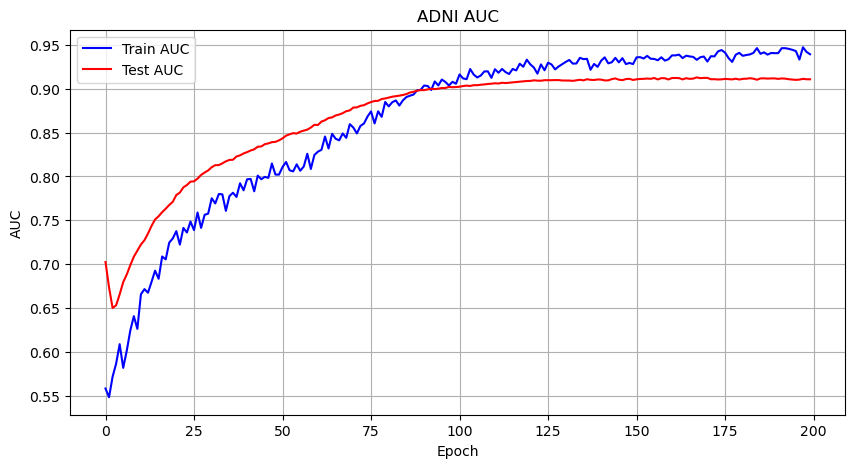

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("ADNI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

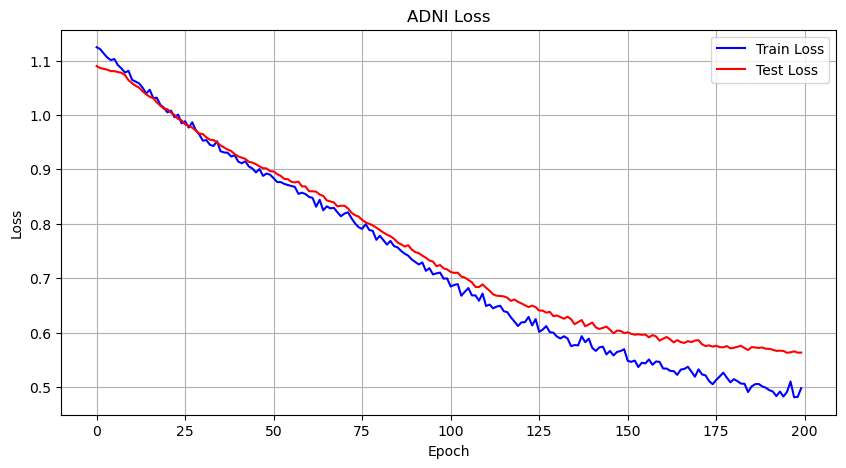

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("ADNI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()